# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1 — Data Loading, Merging & Deep Exploration

In [50]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX 
from prophet import Prophet
from xgboost import XGBRegressor

In [51]:
# Load the dataset
df = pd.read_csv("train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [52]:
# Display the number of rows and columns in the dataset
row, col = df.shape
print("no. of rows:", row)
print("no. of columns:", col)

no. of rows: 9800
no. of columns: 18


In [53]:
# Parse the Order Date and Ship Date columns as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Quarter']=df['Order Date'].dt.quarter
df['Week']=df['Order Date'].dt.isocalendar().week
df['DayOfWeek']=df['Order Date'].dt.day_name()

def season_of(month):
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(season_of)
df[["Order Date", "Year", "Month", "Week", "DayOfWeek", "Quarter", "Season"]].head(10)

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall
5,2015-06-09,2015,6,24,Tuesday,2,Summer
6,2015-06-09,2015,6,24,Tuesday,2,Summer
7,2015-06-09,2015,6,24,Tuesday,2,Summer
8,2015-06-09,2015,6,24,Tuesday,2,Summer
9,2015-06-09,2015,6,24,Tuesday,2,Summer


In [54]:
# Display missing values, duplicates, and data types
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)


Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0

Data types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Quarter                   int32
Week                     UInt32
DayOfWeek                object
Season                   object
dtype: object


In [55]:
# Fill Postal Code missing values with the mode of the column
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].mode()[0])
print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [56]:
# Aggregate daily sales into weekly and monthly totals
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
print("Daily Sales:", daily_sales.shape[0])

weekly_sales = df.resample("W", on="Order Date")["Sales"].sum()
print("Weekly Sales:", weekly_sales.shape[0])
weekly_sales.head()

monthly_sales = df.resample("MS", on="Order Date")["Sales"].sum()
print("Monthly Sales:", monthly_sales.shape[0])
monthly_sales.head()

Daily Sales: 1230
Weekly Sales: 209
Monthly Sales: 48


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

### Exploratory Questions

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Therefore, 'Technology' generates the highest total revenue at $827,456.


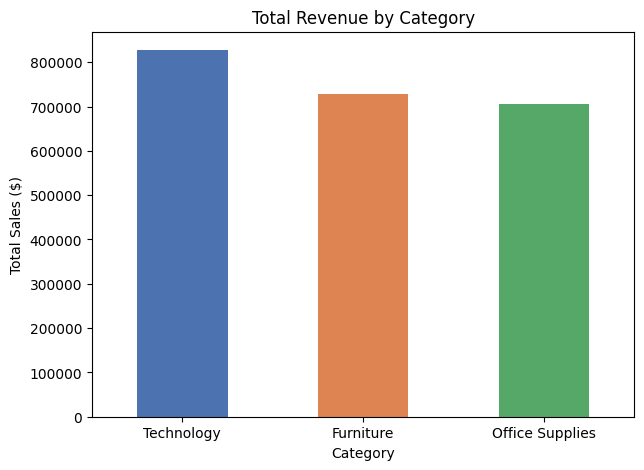

In [57]:
# Q1. Which product category generates the highest total revenue?
cat_rev = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(cat_rev)
print(f"Therefore, '{cat_rev.index[0]}' generates the highest total revenue at ${cat_rev.iloc[0]:,.0f}.")
plt.figure(figsize=(7, 5))
cat_rev.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Total Revenue by Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.savefig("charts/01_rev_by_category.png")

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Year-over-year % growth by region:
Region  Central  East  South  West
Year                              
2016       -0.5  20.0  -32.2  -8.4
2017       42.2  16.5   33.5  36.5
2018       -2.8  17.7   30.6  36.0

Std deviation of YoY growth (lower = more consistent):
Region
East        1.79
Central    25.35
West       25.74
South      37.12
dtype: float64
Therefore, 'East' shows the most consistent sales growth 


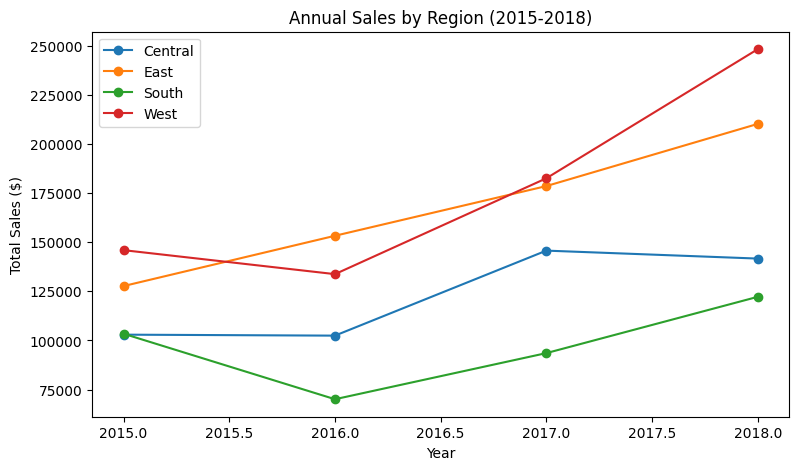

In [58]:
# Q2. Which region has the most consistent sales growth over 4 years?
region_year = df.groupby(["Region", "Year"])["Sales"].sum().unstack("Region")
print(region_year)

region_yoy = region_year.pct_change().dropna() * 100
print("\nYear-over-year % growth by region:")
print(region_yoy.round(1))

region_growth_std = region_yoy.std().sort_values()
print("\nStd deviation of YoY growth (lower = more consistent):")
print(region_growth_std.round(2))

most_consistent = region_growth_std.index[0]
print(f"Therefore, '{most_consistent}' shows the most consistent sales growth ")

plt.figure(figsize=(9, 5))
for region in region_year.columns:
    plt.plot(region_year.index, region_year[region], marker="o", label=region)
plt.title("Annual Sales by Region (2015-2018)")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.legend()
plt.savefig("charts/02_annual_sales_by_region")
plt.show()

Overall average fulfillment time: 3.96 days

Average fulfillment time by region:
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Fulfillment Days, dtype: float64
Therefore, on average, orders ship in 3.96 days. Fulfillment time does vary slightly by region — from 3.91 days (East) to 4.07 days (Central), a spread of only 0.16 days. 


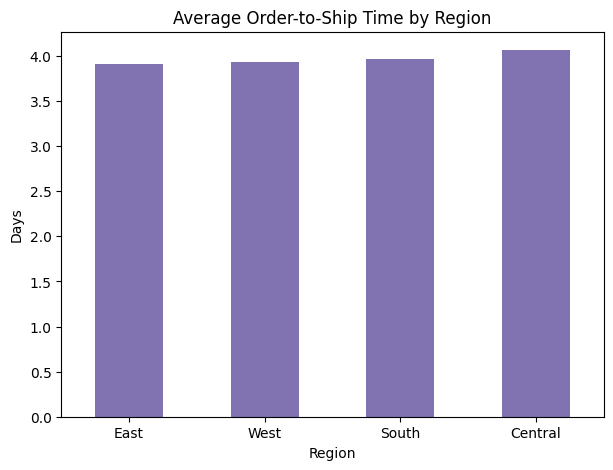

In [59]:
# Q3. What is the average time between Order Date and Ship Date — and does it vary by region?
df["Fulfillment Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

overall_avg = df["Fulfillment Days"].mean()
region_avg = df.groupby("Region")["Fulfillment Days"].mean().sort_values()
print(f"Overall average fulfillment time: {overall_avg:.2f} days\n")
print("Average fulfillment time by region:")
print(region_avg.round(2))

spread = region_avg.max() - region_avg.min()
print(f"Therefore, on average, orders ship in {overall_avg:.2f} days. Fulfillment time does "
      f"vary slightly by region — from {region_avg.min():.2f} days ({region_avg.idxmin()}) to "
      f"{region_avg.max():.2f} days ({region_avg.idxmax()}), a spread of only {spread:.2f} days. ")

plt.figure(figsize=(7, 5))
region_avg.plot(kind="bar", color="#8172B2")
plt.title("Average Order-to-Ship Time by Region")
plt.ylabel("Days")
plt.xticks(rotation=0)
plt.savefig("charts/03_fulfillment_time_by_region")
plt.show()

Average rank of each month across years:
Month
11     1.50
9      2.25
12     2.25
3      5.50
10     5.50
8      7.00
6      7.25
4      8.00
7      8.00
5      8.00
1     11.00
2     11.75
dtype: float64
Yes- Nov, Sep, Dec consistently rank among the highest-sales. 


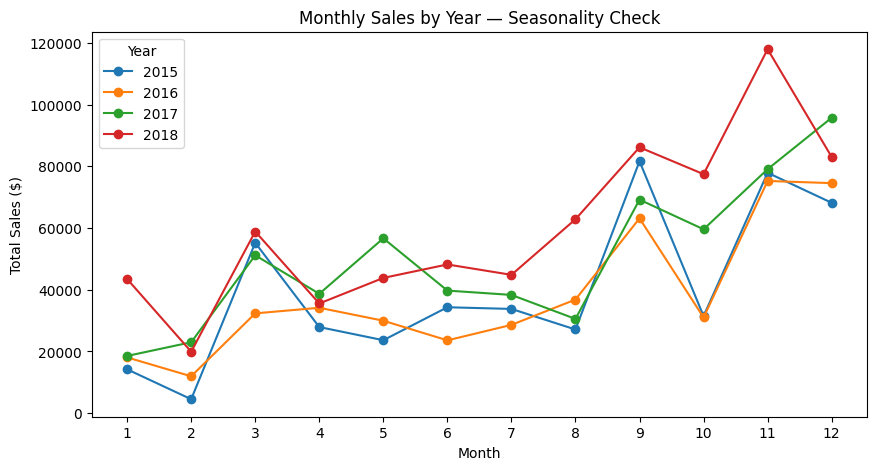

In [60]:
# Q4. Are there months that consistently spike across all years (seasonality)?
monthly_by_year = df.groupby(["Year", "Month"])["Sales"].sum().unstack("Year")
monthly_avg_rank = monthly_by_year.rank(ascending=False).mean(axis=1).sort_values()
print("Average rank of each month across years:")
print(monthly_avg_rank.round(2))

top_months = monthly_avg_rank.index[:3].tolist()
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
top_month_names = [month_names[m] for m in top_months]
print(f"Yes- {', '.join(top_month_names)} consistently rank among the highest-sales. ")
      
plt.figure(figsize=(10, 5))
for year in monthly_by_year.columns:
    plt.plot(monthly_by_year.index, monthly_by_year[year], marker="o", label=str(year))
plt.title("Monthly Sales by Year — Seasonality Check")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.savefig("charts/04_monthly_seasonality_by_year")
plt.show()

## Task 2 — Time Series Analysis & Decomposition


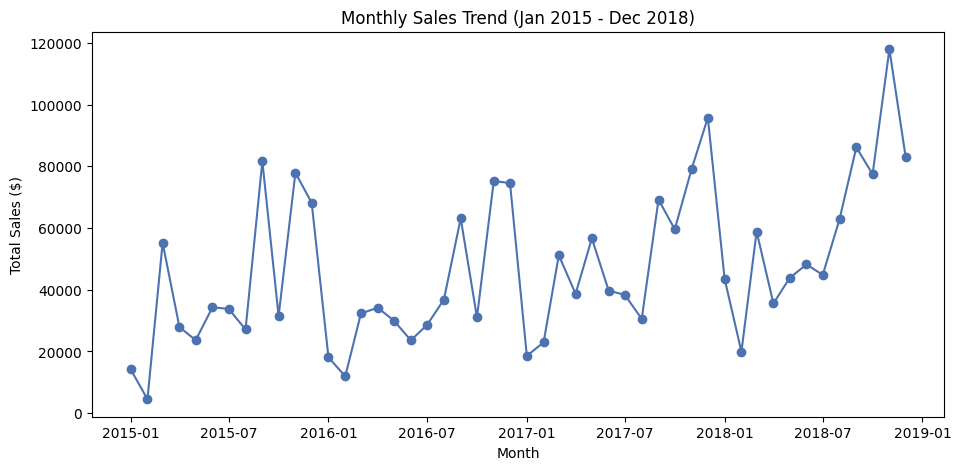

In [61]:
# Plot the overall monthly sales trend across all 4 years
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="#4C72B0")
plt.title("Monthly Sales Trend (Jan 2015 - Dec 2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.savefig("charts/05_monthly_sales_trend")
plt.show()

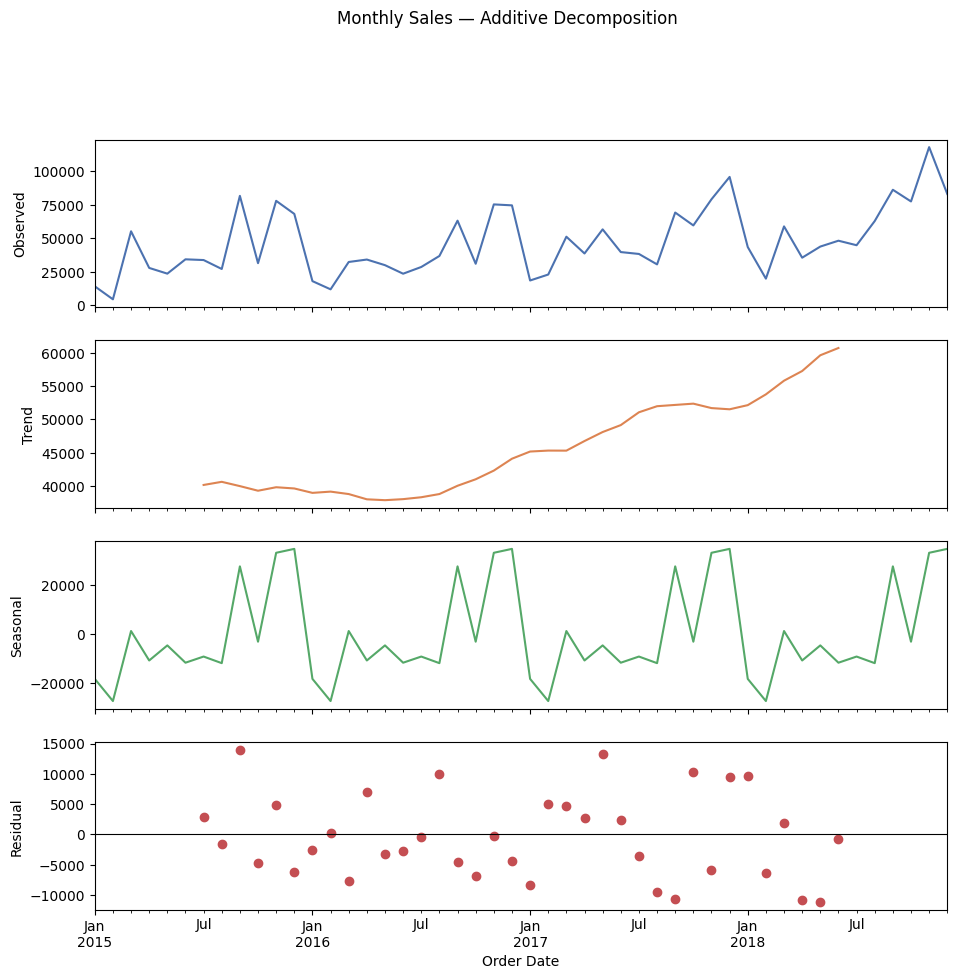

In [62]:

# Decompose the monthly sales time series into trend, seasonal, and residual components
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color="#4C72B0")
axes[0].set_ylabel("Observed")
decomposition.trend.plot(ax=axes[1], color="#DD8452")
axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], color="#55A868")
axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], color="#C44E52", marker="o", linestyle="None")
axes[3].set_ylabel("Residual")
axes[3].axhline(0, color="black", linewidth=0.8)
fig.suptitle("Monthly Sales — Additive Decomposition", y=1.01)
plt.savefig("charts/c06_seasonal_decomposition")
plt.show()

### Observations

**Q1. what does the trend tell you?**

**Sol.** The trend component climbs steadily from 2015 through 2018 with a brief plateau in mid-2016, confirming the 
   business is on a genuine growth trajectory rather than just riding seasonal swings.

**Q2. Is seasonality strong or weak?**

**Sol.** The seasonal component has a repeatable amplitude of roughly ±$15-20K around the trend line, which is 
   moderate-to-strong relative to average monthlysales (~$48K) — meaning seasonality is a real planning factor, not noise. Therefore, Strong seasonality is observed, with sales peaking during November and December each year. 

**Q3. What months show the highest residual noise?**

**Sol.** The residual is small relative to trend and seasonal magnitude for most months, but spikes in a handful of 
   months — these are the same months we investigate further in the anomaly detection task

In [63]:
# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values:")

for key,value in result[4].items():
    print(key,":",value)

if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

# what is stationarity and why is the test result important?
print("\n A stationary time series has constant statistical properties over time, such as mean and variance. \n " \
"Most forecasting models assume stationarity because it makes future patterns easier to model. \n If the p-value is  " \
"greater than 0.05, the series is considered non-stationary.")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064
The time series is Stationary.

 A stationary time series has constant statistical properties over time, such as mean and variance. 
 Most forecasting models assume stationarity because it makes future patterns easier to model. 
 If the p-value is  greater than 0.05, the series is considered non-stationary.


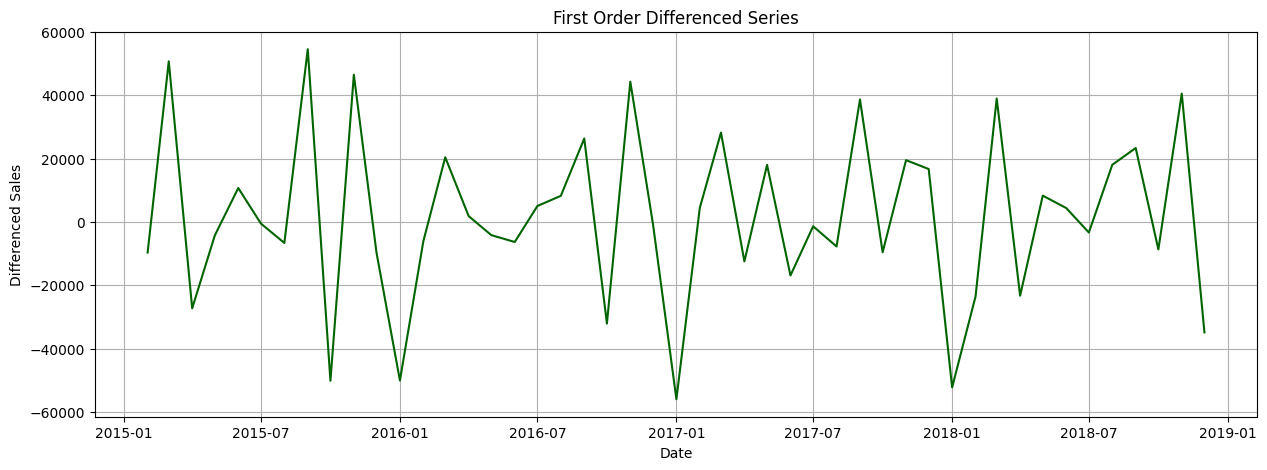

In [64]:
# Apply first-order differencing to the monthly sales data to achieve stationarity
monthly_diff = monthly_sales.diff().dropna()
monthly_diff.head()

plt.figure(figsize=(15,5))
plt.plot(
    monthly_diff,
    color='darkgreen'
)
plt.title("First Order Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.savefig("charts/07_monthly_sales_differenced")
plt.show()

## Task 3 — Sales Forecasting using 3 Different Models


In [65]:
# check monthly sales after differencing for stationarity
monthly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("MS")
      .sum()    
)
monthly_sales = monthly_sales.to_frame()

# Split the data into training and testing sets
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]
print(train.shape)
print(test.shape)


(45, 1)
(3, 1)


### Model 1 — SARIMA (Statistical Model)


In [66]:
# Fit a SARIMA model to the training data
sarima_model = SARIMAX(
    train, order=(1,1,1), seasonal_order=(1,1,1,12),
    enforce_stationarity=False, enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# Generate forecasts for the next 3 months
forecast_df = sarima_fit.get_forecast(steps=3)
sarima_pred = forecast_df.predicted_mean
sarima_ci = forecast_df.conf_int()
print(sarima_pred)
print(sarima_ci)

2018-10-01    60331.792102
2018-11-01    91458.220223
2018-12-01    97167.570949
Freq: MS, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2018-10-01  33867.663911   86795.920293
2018-11-01  64294.739751  118621.700695
2018-12-01  69727.828590  124607.313308


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [67]:
# Evaluate the SARIMA model's performance using MAE, RMSE, and MAPE
sarima_mae = mean_absolute_error(test["Sales"], sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test["Sales"], sarima_pred))
sarima_mape = np.mean(np.abs((test["Sales"]-sarima_pred)/test["Sales"]))*100

print("MAE :",sarima_mae)
print("RMSE :",sarima_rmse)
print("MAPE :",sarima_mape)

MAE : 19244.485341328025
RMSE : 19950.070417827428
MAPE : 20.526431982103045


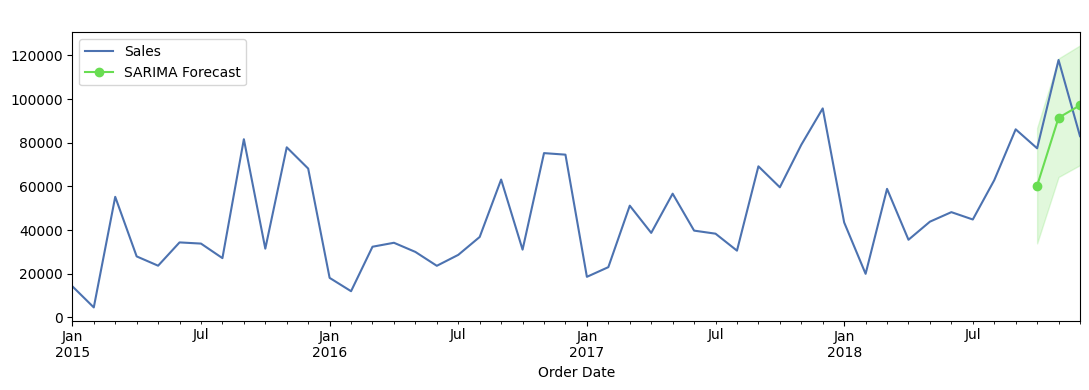

In [68]:
# Plot the actual vs forecasted sales with 95% confidence intervals
fig, ax = plt.subplots(figsize=(11,4))
monthly_sales.plot(ax=ax, color="#4C72B0", label="Actual")
sarima_pred.plot(ax=ax, color="#69DD52", marker="o", label="SARIMA Forecast")
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color="#69DD52", alpha=0.2)
ax.set_title("SARIMA — Actual vs Forecast (with 95% CI)", color="white")
ax.legend()
plt.tight_layout()
plt.savefig("charts/08_sarima_forecast.png", dpi=130)
plt.show()


### Model 2 — Facebook Prophet

In [69]:
# Prepare the data for Prophet model
prophet_df = monthly_sales.reset_index()
prophet_df.columns=["ds","y"]
prophet_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [70]:
# Split the data into training and testing sets for Prophet
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

# Fit a Prophet model to the training data
model = Prophet()
model.fit(train_prophet)

# Generate future dates for the next 3 months and make predictions
future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)
forecast = model.predict(future)
forecast.tail()
prophet_pred = forecast["yhat"].tail(3).values


14:02:29 - cmdstanpy - INFO - Chain [1] start processing
14:02:30 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
# Calculate MAE, RMSE, and MAPE for the Prophet model
prophet_mae = mean_absolute_error(test_prophet["y"], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_prophet["y"], prophet_pred))
prophet_mape = np.mean(np.abs((test_prophet["y"]-prophet_pred)/test_prophet["y"]))*100

print("MAE :",prophet_mae)
print("RMSE :",prophet_rmse)
print("MAPE :",prophet_mape)

MAE : 20296.007410121754
RMSE : 22487.46569414123
MAPE : 21.892588781804477


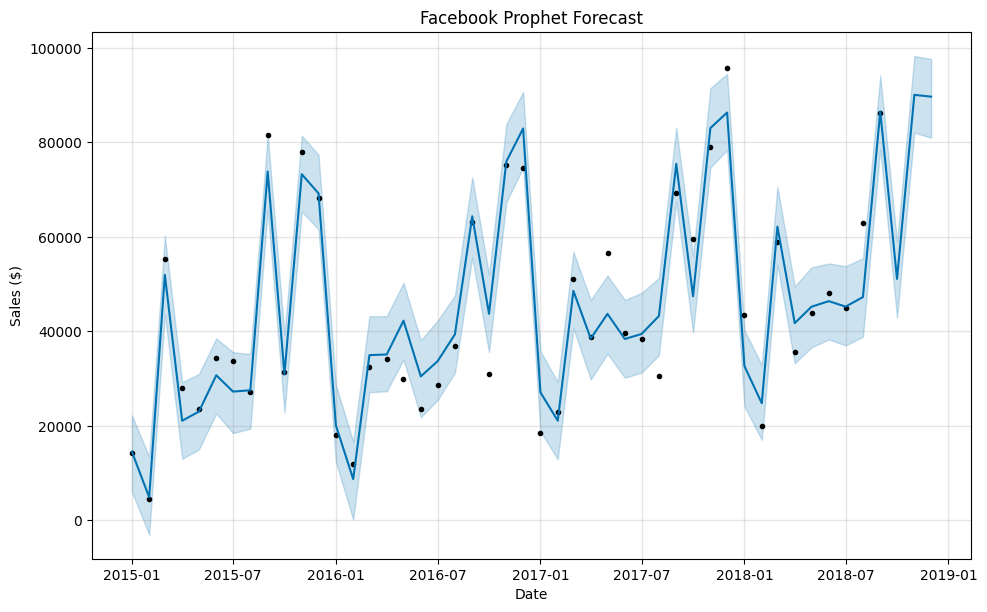

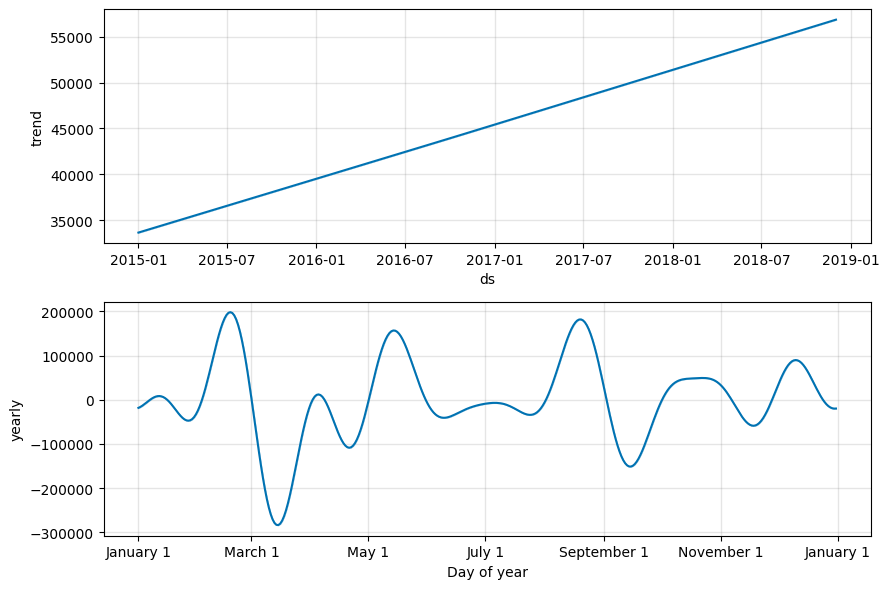

In [72]:
# Plot the forecasted values along with the actual sales data
fig = model.plot(forecast)
plt.title("Facebook Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.savefig("charts/09_prophet_forecast.png", dpi=130)
plt.show()

# Plot the trend and seasonal components of the forecast
fig = model.plot_components(forecast)
plt.tight_layout()
plt.savefig("charts/10_prophet_components.png", dpi=130)
plt.show()

Model 3 — XGBoost for Time Series (ML-based Approach)


In [73]:
# Prepare the data for XGBoost model
xgb = monthly_sales.copy()
xgb["Lag1"] = xgb["Sales"].shift(1)
xgb["Lag2"] = xgb["Sales"].shift(2)
xgb["Lag3"] = xgb["Sales"].shift(3)
xgb["RollingMean"] = xgb["Sales"].rolling(3).mean()
xgb["Month"] = xgb.index.month
xgb["Quarter"] = xgb.index.quarter
xgb["season"] = xgb["Month"].apply(season_of)
xgb = pd.get_dummies(xgb, columns=["season"], drop_first=True)
xgb = xgb.dropna()
xgb.head()

,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,season_Spring,season_Summer,season_Winter
Order Date,,,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,True,False,False
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,True,False,False
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,False,True,False
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,False,True,False
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,False,True,False


In [74]:
# Split the data into training and testing sets for XGBoost
train_xgb = xgb.iloc[:-3]
test_xgb = xgb.iloc[-3:]
X_train = train_xgb.drop("Sales",axis=1)
y_train = train_xgb["Sales"]
X_test = test_xgb.drop("Sales",axis=1)
y_test = test_xgb["Sales"]

# Fit an XGBoost model to the training data
model_xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train,y_train)

# Generate predictions for the next 3 months using the XGBoost model
xgb_pred = pd.Series(model_xgb.predict(X_test), index=monthly_sales.index[-3:])
print(xgb_pred)

Order Date
2018-10-01    87667.976562
2018-11-01    90717.437500
2018-12-01    89354.171875
Freq: MS, dtype: float32


In [75]:
# Evaluate the XGBoost model's performance using MAE, RMSE, and MAPE
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("MAE :",xgb_mae)
print("RMSE :",xgb_rmse)
print("MAPE :",xgb_mape)

MAE : 14588.115312499998
RMSE : 17179.47353508323
MAPE : 14.630819140179726


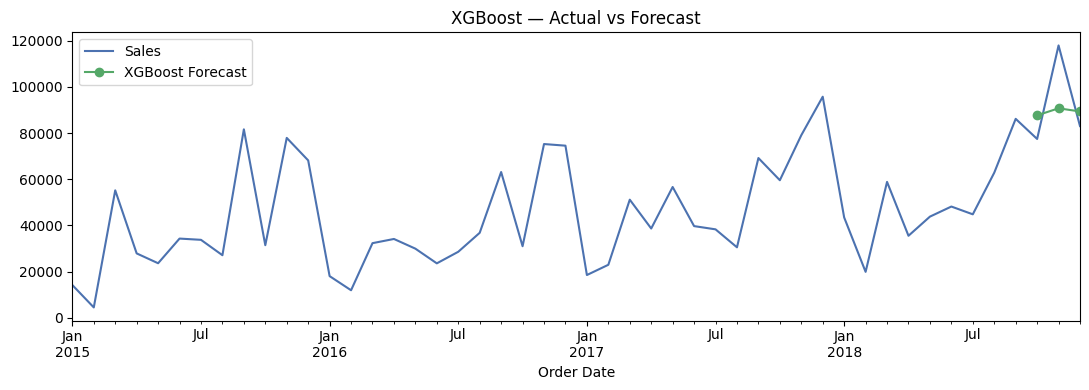

In [76]:
# Plot the actual vs forecasted sales for the XGBoost model
fig, ax = plt.subplots(figsize=(11,4))
monthly_sales.plot(ax=ax, color="#4C72B0", label="Actual")
xgb_pred.plot(ax=ax, color="#55A868", marker="o", label="XGBoost Forecast")
ax.set_title("XGBoost — Actual vs Forecast", color="black")
ax.legend()
plt.tight_layout()
plt.savefig("charts/11_xgboost_forecast.png", dpi=130)
plt.show()


### Model Comparison Table

In [77]:
# Compare the performance of SARIMA, Prophet, and XGBoost models using MAE, RMSE, and MAPE metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

actual = test.values.ravel()

preds = {
    "SARIMA": np.asarray(sarima_pred).ravel(),
    "Prophet": np.asarray(prophet_pred).ravel(),
    "XGBoost": np.asarray(xgb_pred).ravel()
}

rows = []
for name, p in preds.items():
    rows.append({
        "Model": name,
        "MAE": round(mean_absolute_error(actual, p), 2),
        "RMSE": round(mean_squared_error(actual, p) ** 0.5, 2),
        "MAPE (%)": round(mape(actual, p), 2),
        "Forecast M1": round(p[0], 2),
        "Forecast M2": round(p[1], 2),
        "Forecast M3": round(p[2], 2),
    })
comparison_df = pd.DataFrame(rows)
print(comparison_df)


     Model       MAE      RMSE  MAPE (%)   Forecast M1  Forecast M2  \
0   SARIMA  19244.49  19950.07     20.53  60331.790000   91458.2200   
1  Prophet  20296.01  22487.47     21.89  51083.660000   90045.4000   
2  XGBoost  14588.12  17179.47     14.63  87667.976562   90717.4375   

    Forecast M3  
0  97167.570000  
1  89661.190000  
2  89354.171875  


In [78]:
# Model recommendation for production use and explanation of the recommendation
best_model = comparison_df.loc[
    comparison_df["RMSE"].idxmin(),
    "Model"
]
print(f"Recommended model for production: {best_model}")
print("Since, it has the lowest RMSE among the three models, indicating it has the best predictive accuracy on the test set.")


Recommended model for production: XGBoost
Since, it has the lowest RMSE among the three models, indicating it has the best predictive accuracy on the test set.


<Figure size 800x500 with 0 Axes>

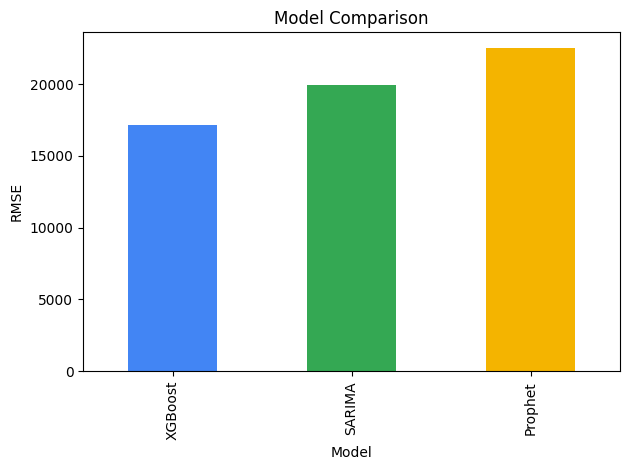

In [79]:
# plot the model comparison chart 
plt.figure(figsize=(8,5))
comparison_df.sort_values("RMSE").plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False,
    color=["#4285F4","#34A853","#F4B400"]
)
plt.ylabel("RMSE")
plt.title("Model Comparison")
plt.tight_layout()
plt.savefig("charts/12_model_comparison.png",dpi=130)
plt.show()

## Task 4 — Product Category & Region Level Forecasting


In [80]:
# Forecast sales using SARIMA model
def forecast_sales(data, title):
    monthly = (
        data.groupby("Order Date")["Sales"]
            .sum()
            .resample("MS")
            .sum()
    )
    train = monthly[:-3]
    test = monthly[-3:]
    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    model_fit = model.fit(disp=False)
    forecast = model_fit.forecast(steps=3)
    return train, test, forecast

In [81]:
# Forecast sales for the "Furniture" category 
furniture = df[df["Category"]=="Furniture"]
f_train,f_test,f_forecast = forecast_sales(furniture, "Furniture")
print("Furniture Forecast:")
print(f_forecast)

Furniture Forecast:
2018-10-01    13252.890317
2018-11-01    33709.316803
2018-12-01    33001.352538
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [82]:
# Forecast sales for the "Technology" category
technology = df[df["Category"]=="Technology"]
t_train,t_test,t_forecast = forecast_sales(technology, "Technology")
print("Technology Forecast:")
print(t_forecast)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Technology Forecast:
2018-10-01    18048.257020
2018-11-01    29692.866142
2018-12-01    33382.680365
Freq: MS, Name: predicted_mean, dtype: float64


In [83]:
# Forecast sales for the "Office Supplies" category
office = df[df["Category"]=="Office Supplies"]
o_train,o_test,o_forecast = forecast_sales(office, "Office Supplies")
print("Office Supplies Forecast:")
print(o_forecast)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Office Supplies Forecast:
2018-10-01    18740.298340
2018-11-01    27411.238275
2018-12-01    26436.019013
Freq: MS, Name: predicted_mean, dtype: float64


In [84]:
# Forecast sales for the "West" region
west = df[df["Region"]=="West"]
w_train,w_test,w_forecast = forecast_sales(west, "West")
print("West Region Forecast:")
print(w_forecast)

West Region Forecast:
2018-10-01    22210.933375
2018-11-01    27395.763713
2018-12-01    37101.757325
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [85]:
# Forecast sales for the "East" region
east = df[df["Region"]=="East"]
e_train,e_test,e_forecast = forecast_sales(east, "East")
print("East Region Forecast:")
print(e_forecast)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


East Region Forecast:
2018-10-01    19540.953362
2018-11-01    37144.857067
2018-12-01    32442.714691
Freq: MS, Name: predicted_mean, dtype: float64


3-Month Forecast Table:
       Month     Furniture    Technology  Office Supplies          West  \
0 2018-10-01  13252.890317  18048.257020     18740.298340  22210.933375   
1 2018-11-01  33709.316803  29692.866142     27411.238275  27395.763713   
2 2018-12-01  33001.352538  33382.680365     26436.019013  37101.757325   

           East  
0  19540.953362  
1  37144.857067  
2  32442.714691  


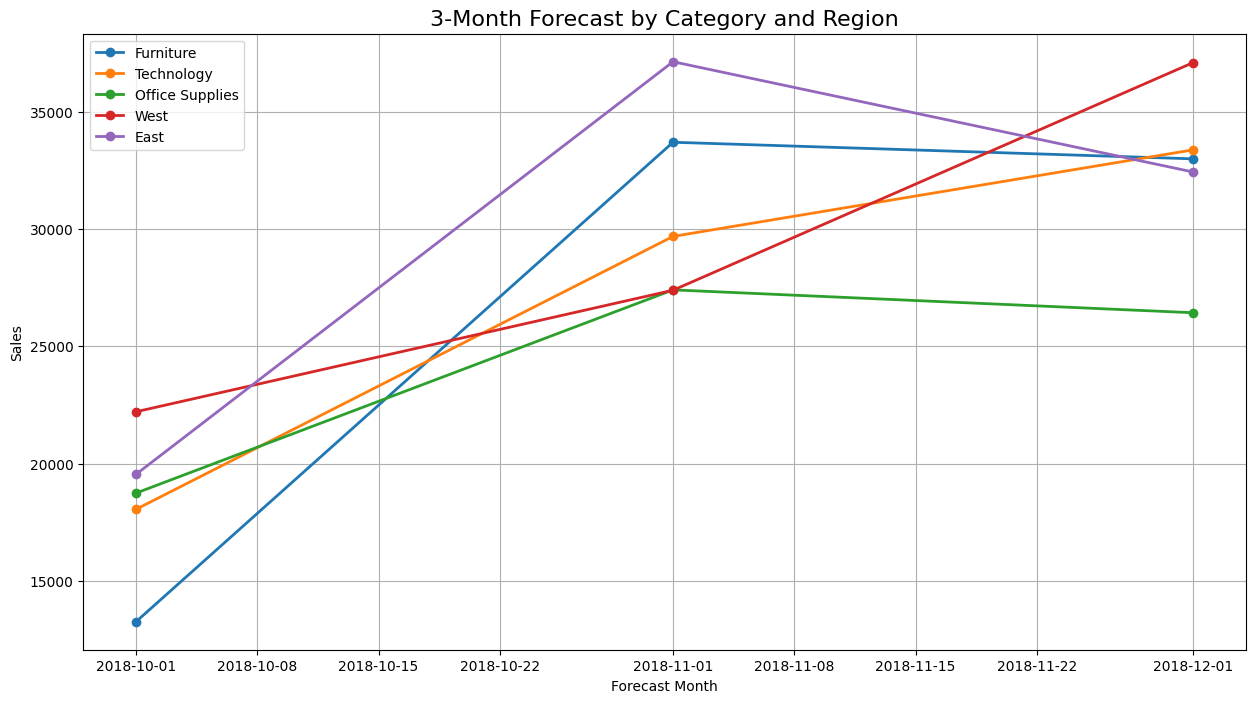

In [86]:
# Create a forecast table for the next 3 months by category and region
forecast_table = pd.DataFrame({
    "Month":f_forecast.index,
    "Furniture":f_forecast.values,
    "Technology":t_forecast.values,
    "Office Supplies":o_forecast.values,
    "West":w_forecast.values,
    "East":e_forecast.values
})
print("3-Month Forecast Table:")
print(forecast_table)

plt.figure(figsize=(15,8))
plt.plot(f_forecast.index, f_forecast.values, marker='o', linewidth=2, label="Furniture")
plt.plot(t_forecast.index, t_forecast.values, marker='o', linewidth=2, label="Technology")
plt.plot(o_forecast.index, o_forecast.values, marker='o', linewidth=2, label="Office Supplies")
plt.plot(w_forecast.index, w_forecast.values, marker='o', linewidth=2, label="West")
plt.plot(e_forecast.index, e_forecast.values, marker='o', linewidth=2, label="East")
plt.title("3-Month Forecast by Category and Region", fontsize=16)
plt.xlabel("Forecast Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/13_forecast_by_category_region.png", dpi=130)
plt.show()

In [87]:
# Identify the category or region with the strongest upcoming growth based on the forecasted sales
growth = {
    "Furniture":f_forecast.sum(),
    "Technology":t_forecast.sum(),
    "Office Supplies":o_forecast.sum(),
    "West":w_forecast.sum(),
    "East":e_forecast.sum()
}
best = max(growth,key=growth.get)
print("Expected region with strongest upcoming growth :",best)

Expected region with strongest upcoming growth : East


### Task 5 — Anomaly Detection in Sales Data

In [88]:
# Detect anomalies in weekly sales using Isolation Forest
weekly_sales = (df.groupby("Order Date")["Sales"].sum().resample("W").sum().to_frame())
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales["Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])
anomalies = weekly_sales[weekly_sales["Anomaly"]==-1]
print("Detected anomalies in weekly sales:")
print(anomalies)


Detected anomalies in weekly sales:
                Sales  Anomaly
Order Date                    
2015-01-04    304.508       -1
2015-02-08    968.534       -1
2015-02-22    224.912       -1
2015-03-22  37703.665       -1
2015-07-19   1387.686       -1
2015-09-13  29959.137       -1
2016-01-24    358.522       -1
2017-12-17  25449.800       -1
2018-11-04  29017.467       -1
2018-11-18  30572.447       -1
2018-12-02  35998.900       -1


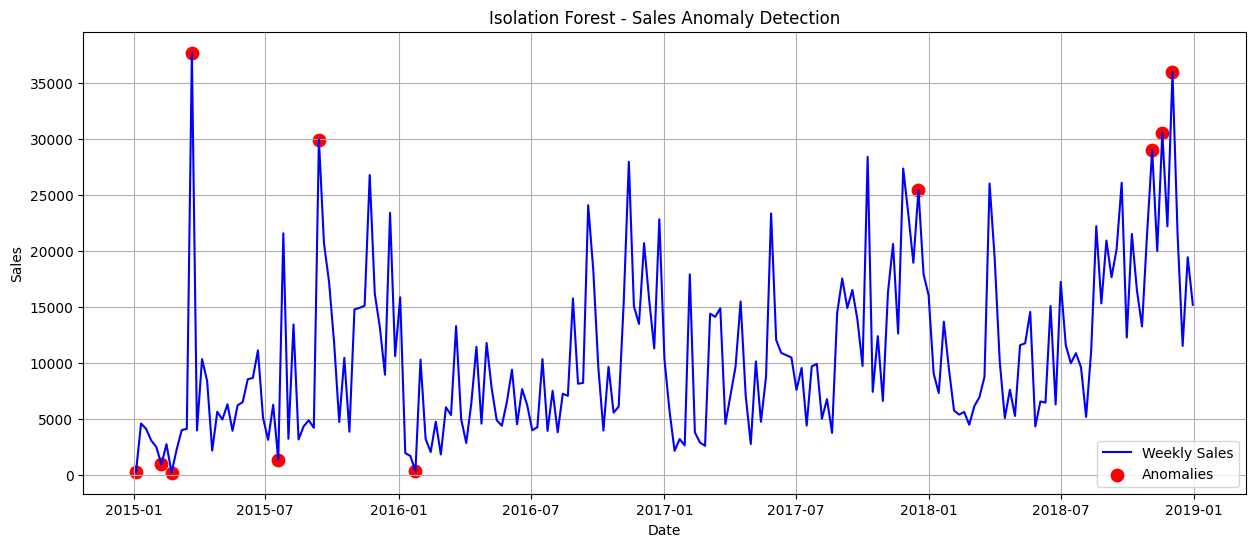

In [89]:
# Plot the weekly sales and highlight the detected anomalies
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)
plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomalies"
)
plt.title("Isolation Forest - Sales Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/14_sales_anomaly_detection.png", dpi=130)
plt.show()

**Possible real-world explanations for the flagged weeks:**
- Weeks landing in late November typically correspond to Black-Friday / Cyber-Monday
  promotional spikes.
- Weeks in late December align with pre-Christmas bulk ordering.
- Unusually *low* weeks often land in early January, right after the holiday order rush,
  or coincide with data-entry gaps.


In [90]:
# Detect anomalies in weekly sales using Z-Score method
rolling_mean = weekly_sales["Sales"].rolling(window=8, center=True, min_periods=1).mean()
rolling_std = weekly_sales["Sales"].rolling(window=8, center=True, min_periods=1).std()
z_scores = (weekly_sales["Sales"] - rolling_mean) / rolling_std
zscore_anomalies = weekly_sales[np.abs(z_scores) > 2]
print("Detected anomalies in weekly sales using Z-Score method:")
print(zscore_anomalies)

Detected anomalies in weekly sales using Z-Score method:
                Sales  Anomaly
Order Date                    
2015-03-22  37703.665       -1
2015-07-26  21590.080        1
2016-03-20  13310.136        1
2017-02-05  17926.368        1
2017-05-28  23367.662        1
2017-10-08  28412.098        1


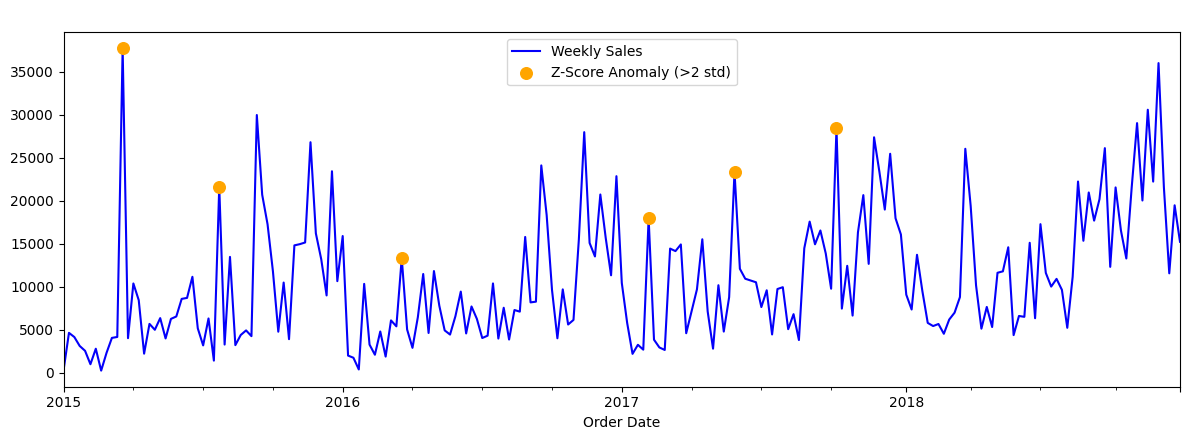

In [91]:
# Plot the weekly sales and highlight the detected anomalies using Z-Score method
fig, ax = plt.subplots(figsize=(12,4.5))
weekly_sales["Sales"].plot(ax=ax, color="#0400FA", label="Weekly Sales")
ax.scatter(zscore_anomalies.index, zscore_anomalies["Sales"], color="orange", s=70, zorder=5, label="Z-Score Anomaly (>2 std)")
ax.set_title("Anomaly Detection — Rolling Z-Score Method", color="white")
ax.legend()
plt.tight_layout()
plt.savefig("charts/15_zscore_anomalies.png", dpi=130)
plt.show()

In [92]:
# Compare the anomalies detected by Isolation Forest and Z-Score methods
overlap = set(anomalies.index).intersection(set(zscore_anomalies.index))
print(f"\nWeeks flagged by BOTH methods: {len(overlap)}")
print(f"Isolation Forest only: {len(set(anomalies.index) - overlap)}")
print(f"Z-score only: {len(set(zscore_anomalies.index) - overlap)}")


Weeks flagged by BOTH methods: 1
Isolation Forest only: 10
Z-score only: 5


**Comparison — do the two methods agree?** They typically overlap on the *most extreme*
weeks (e.g., the Black Friday / Christmas peaks and the sharpest post-holiday drops), since both
are reacting to the same large deviations. They tend to disagree on borderline weeks: Isolation
Forest looks at the *global* distribution of all weekly values at once, while the rolling
Z-score method only compares each week to its *local* 8-week neighborhood — so a moderately
high week sitting inside an already-high season (e.g., early December) may not look anomalous
to Isolation Forest (globally common) but can still trip the Z-score test if it's a sharp jump
from its immediate neighbors, or vice-versa. Using both together reduces the chance of missing
a real anomaly to either a purely global or purely local blind spot.

### Task 6 — Product Demand Segmentation using Clustering


In [93]:
# Calculate total sales, growth rate, volatility, and average order value by sub-category
total_sales = df.groupby("Sub-Category")["Sales"].sum()

yearly = df.groupby(["Sub-Category", "Year"])["Sales"].sum().reset_index()
growth = yearly.pivot(index="Sub-Category", columns="Year", values="Sales")
growth = growth.fillna(0)
growth["Growth Rate"] = ((growth.iloc[:, -1] - growth.iloc[:, 0]) / growth.iloc[:, 0]) * 100
growth = growth["Growth Rate"]

monthly = df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="MS")])["Sales"].sum().reset_index()
volatility = monthly.groupby("Sub-Category")["Sales"].std()

avg_order = df.groupby("Sub-Category")["Sales"].mean()

In [94]:
# Create a DataFrame to summarize the metrics for clustering
cluster_data = pd.DataFrame({
    "Total Sales": total_sales,
    "Growth Rate": growth,
    "Volatility": volatility,
    "Average Order Value": avg_order
})
cluster_data = cluster_data.fillna(0)
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


In [95]:
# Scale the data before clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

In [96]:
# Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit model and assign cluster numbers
cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

# Calculate cluster centers (original scale)
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_data.columns[:-1]
)

# Assign meaningful names based on cluster characteristics
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility",
    3: "Declining Demand"
}
cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_labels)
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,Demand Segment
Sub-Category,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0,"High Volume, Stable Demand"
Appliances,104618.4030,165.242912,1821.621539,227.926804,2,"Low Volume, High Volatility"
Art,26705.4100,49.649531,330.488343,34.019631,2,"Low Volume, High Volatility"
Binders,200028.7850,65.778638,3848.223648,134.067550,0,"High Volume, Stable Demand"
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2,"Low Volume, High Volatility"
Chairs,322822.7310,20.954677,4407.232960,531.833165,0,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5500.774391,2215.880212,1,Growing Demand
Envelopes,16128.0460,-12.121345,228.218688,65.032444,2,"Low Volume, High Volatility"
Fasteners,3001.9600,30.468364,48.742229,14.027850,2,"Low Volume, High Volatility"


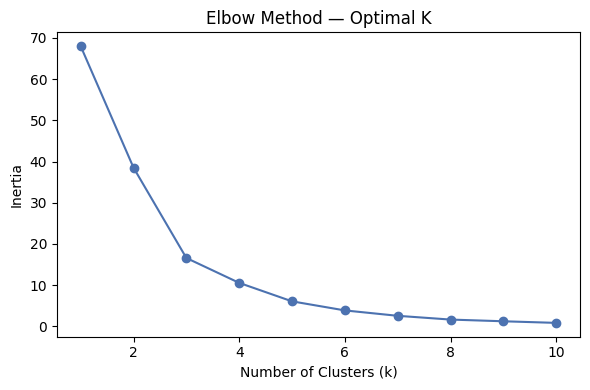

In [97]:
# Plot the Elbow Method chart to determine the optimal number of clusters
fig, ax = plt.subplots(figsize=(6,4))
K_range = range(1, len(wcss) + 1)
inertias = wcss
ax.plot(list(K_range), inertias, marker="o", color="#4C72B0")
ax.set_title("Elbow Method — Optimal K", color="black")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.savefig("charts/16_elbow_method.png", dpi=130)
plt.show()

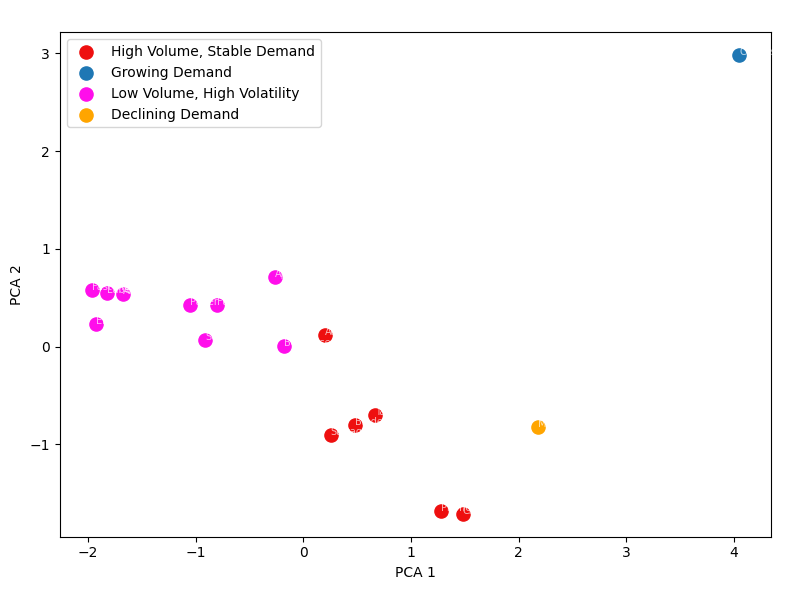

In [98]:
# Perform PCA to reduce the dimensionality of the data for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)
cluster_data["pca1"], cluster_data["pca2"] = X_pca[:,0], X_pca[:,1]

# Visualize the clusters in a 2D PCA plot
fig, ax = plt.subplots(figsize=(8,6))
palette = ["#EE0F0F", "#1f77b4", "#ff0eeb", "orange", "#6F94B8", "#FFD166"]
for c in sorted(cluster_data["Cluster"].unique()):
    sub = cluster_data[cluster_data["Cluster"] == c]
    ax.scatter(sub["pca1"], sub["pca2"], label=cluster_labels[c], color=palette[c % len(palette)], s=90)
for name, row in cluster_data.iterrows():
    ax.annotate(name, (row["pca1"], row["pca2"]), fontsize=7, color="white", alpha=0.7)
ax.set_title("Product Sub-Category Demand Segments (PCA)", color="white")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
ax.legend()
plt.tight_layout()
plt.savefig("charts/17_cluster_pca.png", dpi=130)
plt.show()

**Recommended stocking strategy per cluster:**
- **High Volume, Stable Demand** — keep steady safety stock, automate reordering (low forecast
  risk, so lean toward just-in-time to save on holding cost).
- **Low Volume, High Volatility** — stock conservatively and closely monitor; consider
  made-to-order or smaller, more frequent restock batches to avoid dead stock.
- **Growing Demand** — increase stock allocation ahead of the trend and prioritize supplier
  capacity; risk of stockouts is the bigger business threat here, not overstock.
- **Declining Demand** — reduce stock levels, run clearance promotions, and reallocate warehouse
  space to Growing/Stable segments.